### Import packages!

In [1]:
!hostname

ne1dc5-003.nygenome.org


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime
import scanpy as sc
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from matplotlib.font_manager import FontProperties
import anndata as ad
from scipy.stats import ranksums
import matplotlib.cm as cm
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import umap
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection
import sys
import gffutils
import os

# Add the directory containing IsovizPy.py to the Python path for visualization of ATSEs and isoforms 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/visualization')
import IsovizPy as ja

# Import functions from utilities.py 
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis')
from LeafletFA_utilities import *
import importlib

# Increase the font scale for seaborn
sns.set(font_scale=1.5)  # Adjust this value to increase or decrease font size
sns.set_style("white")  # Set the background to white

In [3]:
# Load data and create the database (note this may take 1-2 minutes)
gtf_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf"
# db = ja.create_db(gtf_file, "gencode.vM19") do this only once! 

# Path to the database file created previously
db_path = "gencode.vM19"

# Load the database
db = gffutils.FeatureDB(db_path, keep_order=True)

### Load all datasets!

In [4]:
# Today's date 
today = datetime.today().strftime('%Y%m%d')
# Make new directory within current working directory to store all the figures and resutls that will be generated in this notebook
results_dir = f"results_{today}"
os.makedirs(results_dir, exist_ok=True)
os.chdir(results_dir)

# Specify path that contains results from model training 
model_training_results_path = "/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/LEAFLETFA_TRAIN/022025/analysis_20250209_145834_K_30_UsingWaypoints_Prior_GlobalPrior_NumEpochs_100_LearnedConc_Inits_1_CellType_cell_type_grouped_Random_25609"
K = 30 # Number of learned factors 
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-01-30_19-24-18.txt.gz"

In [5]:
# Splicing anndata object 
# splice_adata = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSE_Anndata_Object_with_initializations_20241017_162621.h5ad" (version used for Recomb)
splice_adata = "/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/ALL_CELLS/022025/TMS_Anndata_ATSE_counts_with_waypoints_20250209_143055.h5ad"
splice_adata = sc.read_h5ad(splice_adata)

# Load the expression data (.h5ad file)
exp_file = "/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/ALL_CELLS/022025/TMS_Anndata_GeneExpression_20250209_165655.h5ad"
adata = sc.read_h5ad(exp_file)
adata.var["mouse_gene_name"] = adata.var.index

# Mapped ATSE coordinates 
atses = pd.read_csv(ATSE_file, sep="\t")

In [6]:
atses.head()

,event_id,gene_id,gene_name,num_junctions,event_type,annotation_status,junction_id,chrom,start,end,strand,cells,total_score,splice_motif,donor_seq,acceptor_seq,label_5_prime,label_3_prime,position_off_5_prime,position_off_3_prime
0,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,three_prime,chr1_4774516_4776409_-,chr1,4774516,4776409,-,375,5554,GT-AG,GT,AG,annotated on 5',annotated on 3',-32.0,0.0
1,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,both,chr1_4776801_4777524_-,chr1,4776801,4777524,-,21515,1230743,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0
2,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,three_prime,chr1_4774516_4776405_-,chr1,4774516,4776405,-,32,251,GT-AG,GT,AG,annotated on 5',annotated on 3',-28.0,0.0
3,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,both,chr1_4774516_4777524_-,chr1,4774516,4777524,-,6612,197883,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0
4,ATSE_1,ENSMUSG00000033845.13,Mrpl15,14,complex,both,chr1_4782301_4782567_-,chr1,4782301,4782567,-,893,33145,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0


In [7]:
# Load data and create the database (note this may take 1-2 minutes - do this once!)
gtf_used = True
gtf_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf"  
# Path to the database file created previously
db_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/gencode.vM19"
# Load the database
db = gffutils.FeatureDB(db_path, keep_order=True)

In [8]:
# Load the latent variables (pickle file)
latent_vars_file = f"{model_training_results_path}/latent_vars.pkl"
latent_vars = pd.read_pickle(latent_vars_file)

# Specify prined latent variables file using 
pruned_latent_vars_file = f"{model_training_results_path}/pruned_latent_vars.pkl"
pruned_vars = pd.read_pickle(pruned_latent_vars_file)

In [9]:
# Load the all_vs_all results (CSV file)
albf_scores_file = f"{model_training_results_path}/albf_results.csv"
albf_scores = pd.read_csv(albf_scores_file)
# Make new column junction_id_index using index values 
albf_scores["junction_id_index"] = albf_scores.index
print(albf_scores.shape)

(80234, 92)


In [10]:
print(splice_adata.var.shape)

(80234, 19)


In [11]:
# If GTF file was used, specify columns that include "gene_id" otherwise no "gene_id"
if gtf_used:
    juncs_factors_albf = splice_adata.var[["junction_id", "gene_id", "gene_name", "annotation_status", "event_id", "junction_id_index"]].merge(albf_scores,on="junction_id_index")
else:
    juncs_factors_albf = splice_adata.var[["junction_id", "event_id", "junction_id_index"]].merge(albf_scores,on="junction_id_index")

In [12]:
juncs_factors_albf

,junction_id,gene_id,gene_name,annotation_status,event_id,junction_id_index,cell_state_0,cell_state_1,cell_state_2,cell_state_3,...,mu_25,loc_25,mu_26,loc_26,mu_27,loc_27,mu_28,loc_28,mu_29,loc_29
0,chr10_100016035_100021457_+,ENSMUSG00000019966.18,Kitl,five_prime,ATSE_23615,0,0.006633,0.000204,0.007265,0.000621,...,-7.428247,1.567685,-5.478811,1.493076,-5.811129,1.553652,-7.116404,1.552899,-7.619374,1.500010
1,chr10_100016035_100051845_+,ENSMUSG00000019966.18,Kitl,both,ATSE_23615,1,0.036358,0.944021,0.059155,0.065750,...,2.358190,0.162336,-4.194407,1.784892,-4.193735,1.822587,-3.415251,1.313002,-0.575690,0.110722
2,chr10_100016035_100064083_+,ENSMUSG00000019966.18,Kitl,both,ATSE_23615,2,0.003183,0.000483,0.002251,0.001276,...,-6.301957,1.394887,-5.591173,1.597392,-6.050131,1.565317,-7.133252,1.743533,-6.757833,1.269683
3,chr10_100016035_100087346_+,ENSMUSG00000019966.18,Kitl,both,ATSE_23615,3,0.002385,0.000235,0.002854,0.001843,...,-6.926117,1.611146,-5.147545,1.440011,-6.373848,1.648467,-7.337908,1.475843,-7.017733,1.316903
4,chr10_100016155_100051845_+,ENSMUSG00000019966.18,Kitl,both,ATSE_23615,4,0.014021,0.004285,0.028612,0.009046,...,-4.264436,0.685878,-4.810602,1.515853,-5.128892,1.511706,-5.786237,1.439034,-5.723966,1.262025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80229,chrY_1282945_1284321_-,ENSMUSG00000069045.11,Ddx3y,five_prime,ATSE_34839,80229,0.006110,0.001312,0.004919,0.005075,...,-6.117526,1.536462,-5.237841,1.534962,-5.383015,1.613794,-5.788379,1.209756,-5.561657,1.345173
80230,chrY_1282948_1284321_-,ENSMUSG00000069045.11,Ddx3y,both,ATSE_34839,80230,0.057891,0.732102,0.440429,0.583275,...,-2.854887,2.081456,-3.994920,1.995622,-3.886954,2.042129,1.651999,0.194091,-4.884007,1.347878
80231,chrY_1282968_1284321_-,ENSMUSG00000069045.11,Ddx3y,both,ATSE_34839,80231,0.007909,0.001166,0.004331,0.006251,...,-4.733133,1.595454,-5.109137,1.573730,-4.613352,1.467177,-5.251687,1.254300,-5.944949,1.081962
80232,chrY_90762286_90763136_+,ENSMUSG00000095134.2,Mid1-ps1,both,ATSE_42707,80232,0.064044,0.146668,0.063470,0.240971,...,1.284274,0.065638,0.850348,0.195879,-4.201911,1.546195,-2.692760,1.452141,1.284274,0.142798


### Assemble all aging related genes

In [13]:
# Aging genes from eLife paper
age_elife = "/gpfs/commons/groups/knowles_lab/Karin/elife-62293-supp3-v2.xlsx"
age_elife = pd.read_excel(age_elife, header=0, index_col=None)

# Genes for which the fraction of cells expressing significantly increases with age
supptab4 = "/gpfs/commons/groups/knowles_lab/Karin/41586_2020_2496_MOESM6_ESM.xlsx"
supptab4 = pd.read_excel(supptab4, header=0, index_col=None, sheet_name="all_genes")

# Microglia AD signature vs healthy, not sure how to interpret the 500 genes here...  
supptab10 = "/gpfs/commons/groups/knowles_lab/Karin/41586_2020_2496_MOESM12_ESM.xlsx"
supptab10 = pd.read_excel(supptab10, header=1, index_col=None, sheet_name="Amit_expression_mic3tomic1")

# Global aging genes from TMS paper
global_aging_genes = "/gpfs/commons/groups/knowles_lab/Karin/27857814" # from https://figshare.com/articles/dataset/tms_gene_data_rv1/12827615?file=27857814
global_aging_genes = pd.read_csv(global_aging_genes, sep='\t')

# TMS genes 
tms_paper = global_aging_genes["global_aging_genes"].unique()
age_elife_global = age_elife[age_elife["global_aging"]].gene.unique()

# Combine both lists into one, then use set() to remove duplicates
combined_genes = list(set(tms_paper.tolist() + age_elife_global.tolist()))

# Print the number of unique genes
print(f"Total unique genes: {len(combined_genes)}")

Total unique genes: 330


### Load list of RBPs and senescence markers!

In [14]:
# RBP file
excel_file = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

# Load the Excel file
rbps = pd.read_excel(excel_file, header=1, index_col=None)
# Rename the first two columns to be gene_name and gene_id 
rbps.rename(columns={rbps.columns[0]: 'gene_name', rbps.columns[1]: 'gene_id'}, inplace=True)

# Convert the gene_name column to capitalize only the first letter and lowercase the rest
rbps['mouse_gene_name'] = rbps['gene_name'].str.capitalize()
print(rbps[['gene_name', 'mouse_gene_name', 'gene_id']].head())

  gene_name mouse_gene_name          gene_id
0      A1CF            A1cf  ENSG00000148584
1      AARS            Aars  ENSG00000090861
2      AATF            Aatf  ENSG00000108270
3     ABCF1           Abcf1  ENSG00000204574
4      ABT1            Abt1  ENSG00000146109


### Load latent splicing factors!

In [15]:
assign_post = pruned_vars["pruned_assign_post"]
psi_learned = pruned_vars["pruned_psi_learned"]
pi = pruned_vars["pruned_pi"]

# let's get a new junc_ratio by multiplying psi_assigned and learned PSI! then use that to plot junnction usagea cross cells from different age groups.
new_junc_ratio = assign_post @ psi_learned
splice_adata.layers["new_junc_ratio"] = new_junc_ratio
splice_adata.obs.age.value_counts()

psi_learned = psi_learned
psi_learned_df = pd.DataFrame(psi_learned.T, columns=[f'factor_{i}' for i in range(1, K + 1)])
psi_learned_df["junction_id_index"] = psi_learned_df.index
psi_learned_df = psi_learned_df.merge(splice_adata.var, on="junction_id_index")
splice_adata.var = psi_learned_df

### Figure out which latent spaces are associated with aging

In [16]:
# Step 1: Convert assign_post to a DataFrame and name the columns as 'factor_0', 'factor_1', ..., 'factor_49'
factor_names = [f'factor_{i}' for i in range(1, K + 1)]
assign_post_df = pd.DataFrame(assign_post, columns=factor_names)
assign_post_df.index = splice_adata.obs.index
# Step 2: Attach the factor names DataFrame (assign_post_df) to adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, assign_post_df], axis=1)

### Run logistic regression to predict age as a categorical variable! 

In [17]:
print(K)

30


In [18]:
splice_adata.var

,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,...,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,old_junction_id_index,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score
0,0.006633,0.000204,0.007265,0.000621,0.001901,0.000187,0.001092,0.000783,0.000461,0.000455,...,17,0.0,NaN,132,0,19,0.000179,1.0,0.0,1
1,0.036358,0.944021,0.059155,0.065750,0.025275,0.860227,0.068748,0.073449,0.489904,0.484563,...,17,0.0,1.0,191547,1,5625,0.052967,2.0,1.5,1
2,0.003183,0.000483,0.002251,0.001276,0.002377,0.000693,0.002154,0.001119,0.001319,0.006723,...,17,0.0,1.0,370,2,26,0.000245,2.0,0.0,1
3,0.002385,0.000235,0.002854,0.001843,0.004524,0.000307,0.000592,0.000448,0.000639,0.003967,...,17,0.0,1.0,266,3,18,0.000169,2.0,0.0,1
4,0.014021,0.004285,0.028612,0.009046,0.020724,0.003570,0.001376,0.004360,0.008347,0.005093,...,17,0.0,1.0,3734,4,200,0.001883,2.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80229,0.006110,0.001312,0.004919,0.005075,0.002085,0.006987,0.001625,0.008160,0.003844,0.001720,...,7,1.0,3.0,278,270323,25,0.000235,1.0,0.0,1
80230,0.057891,0.732102,0.440429,0.583275,0.217548,0.296316,0.062368,0.891899,0.373169,0.189371,...,7,1.0,0.0,82903,270324,3287,0.030951,2.0,1.5,1
80231,0.007909,0.001166,0.004331,0.006251,0.004807,0.002433,0.003893,0.003897,0.002462,0.005984,...,7,1.0,0.0,759,270325,49,0.000461,2.0,0.0,1
80232,0.064044,0.146668,0.063470,0.240971,0.078250,0.780660,0.123018,0.112253,0.149000,0.763514,...,2,0.0,1.0,34257,270352,1954,0.018399,2.0,1.5,1


In [19]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "age"
accuracy, coefficients_age = logistic_regression_feature_prediction_simple(splice_adata, feature, K)

# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")

# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_age = coefficients_age.apply(lambda x: x.abs().nlargest(10).index.tolist(), axis=1)

# Define the desired order of indices
new_index_order = ['3m', '18m', '24m']

# Reindex the DataFrame with the new order
coefficients_age = coefficients_age.reindex(new_index_order)

Age Prediction Accuracy: 0.5437
Accuracy for age: 0.5437382297551789


Figure saved as factor_age_coefficients_2025-02-10.pdf


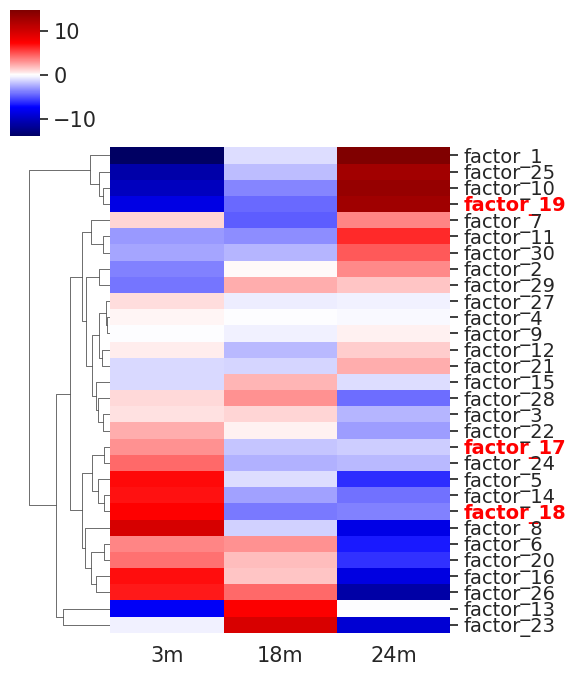

In [20]:
plot_clustermap(coefficients_age, highlighted_factors=['factor_17', 'factor_18', 'factor_19'])

In [21]:
# Step 1: Assign numeric values to the age groups (in the order of the rows in the DataFrame)
age_mapping = {'3m': 3, '18m': 18, '24m': 24}
numeric_ages = coefficients_age.index.map(age_mapping)
correlations = coefficients_age.apply(lambda x: np.corrcoef(numeric_ages, x)[0, 1])
sorted_correlations = correlations.sort_values()
# Display the top 5 negatively and top 5 positively correlated factors
print("Top 5 Negatively Correlated Factors with Age:")
print(sorted_correlations.head(5))

print("\nTop 5 Positively Correlated Factors with Age:")
print(sorted_correlations.tail(5))

Top 5 Negatively Correlated Factors with Age:
factor_5    -0.993817
factor_8    -0.993610
factor_14   -0.986772
factor_4    -0.968457
factor_18   -0.955147
dtype: float64

Top 5 Positively Correlated Factors with Age:
factor_10    0.881270
factor_29    0.925549
factor_25    0.929061
factor_1     0.954442
factor_2     0.984639
dtype: float64


/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = data_melted.groupby(['Factor', age_column])['Contribution'].median().reset_index()


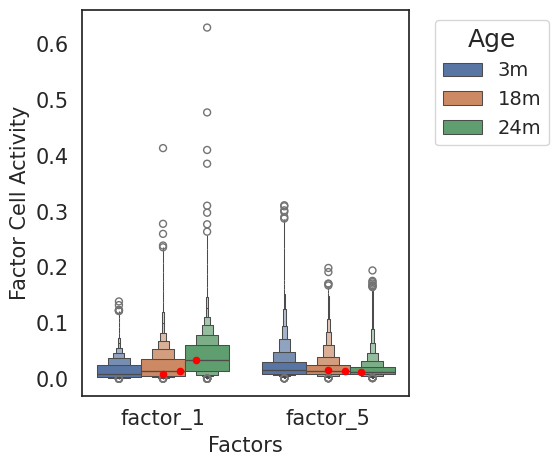

Plot saved as factor_distributions_factor_1_factor_5_2025-02-10.pdf


In [22]:
plot_top_factor_distributions(splice_adata, top_factors=["factor_1", "factor_5"], age_column="age", plot_type="boxenplot")

In [23]:
create_age_category(splice_adata)

factors = [f'factor_{i}' for i in range(1, K+1)]

# Call the function to get results
result_table = compare_factors_by_age(splice_adata, factors, cell_type_col='cell_type_grouped')

# Display the result table
print(result_table)

       cell_type     factor  delta_median        p_value  avg_factor_activity  \
0      STEM CELL   factor_1      0.003873  1.171364e-172             0.012952   
1      STEM CELL   factor_2      0.000234   1.519550e-01             0.144775   
2      STEM CELL   factor_3      0.000638   1.416471e-06             0.009600   
3      STEM CELL   factor_4     -0.007449   6.920201e-45             0.042572   
4      STEM CELL   factor_5     -0.003657   1.242980e-33             0.026754   
...          ...        ...           ...            ...                  ...   
1105  NEUTROPHIL  factor_26     -0.001061   7.399956e-01             0.014273   
1106  NEUTROPHIL  factor_27     -0.000177   5.919031e-01             0.005157   
1107  NEUTROPHIL  factor_28      0.001339   2.888913e-01             0.010496   
1108  NEUTROPHIL  factor_29      0.000241   6.609433e-01             0.018127   
1109  NEUTROPHIL  factor_30     -0.001353   3.410793e-02             0.008245   

      median_factor_activit

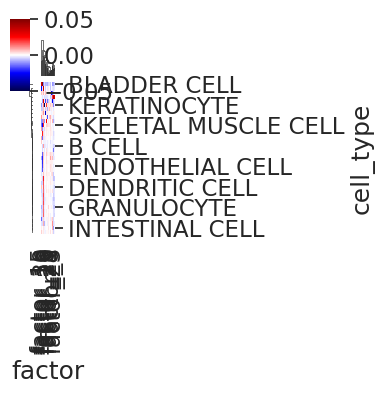

In [24]:
# Step 1: Create a pivot table for delta_median and avg_factor_activity
delta_median_pivot = result_table.pivot(index='cell_type', columns='factor', values='delta_median')
avg_activity_pivot = result_table.pivot(index='cell_type', columns='factor', values='avg_factor_activity')
median_activity_pivot = result_table.pivot(index='cell_type', columns='factor', values='median_factor_activity')

# Step 2: Masking cells with median activity <= 0.001 for delta_median
# mask = avg_activity_pivot < 0.01

# Step 3: Define a colormap that includes black for masked cells
cmap = sns.color_palette("seismic", as_cmap=True)
cmap.set_bad(color='grey')  # Set masked values to black

# Step 3: Cluster the delta_median_pivot to get row and column order
g = sns.clustermap(delta_median_pivot, cmap="seismic", cbar=True, 
                   annot=False, center=0, vmin=-0.05, vmax=0.05, figsize=(4, 4),
                   row_cluster=True, col_cluster=True)

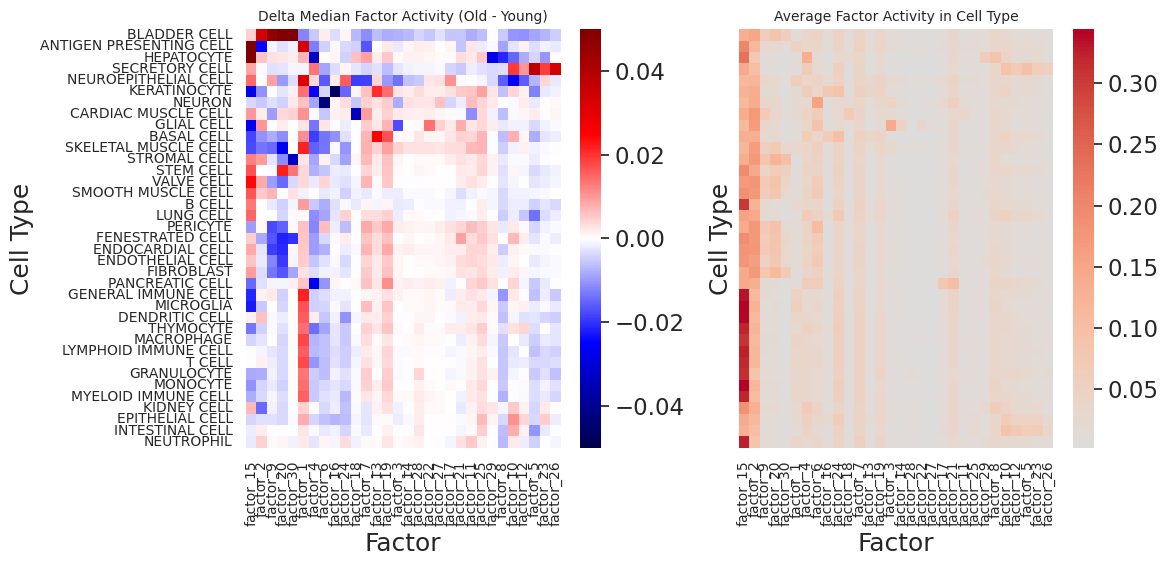

In [25]:
# Extract the cluster order from the clustermap
cell_type_order = g.dendrogram_row.reordered_ind
factor_order = g.dendrogram_col.reordered_ind

# Reindex avg_activity_pivot to match the clustered order of delta_median_pivot
avg_activity_pivot = avg_activity_pivot.iloc[cell_type_order, factor_order]
delta_median_pivot = delta_median_pivot.iloc[cell_type_order, factor_order]  # Reorder this as well

# Step 4: Create a figure for two side-by-side heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Step 5: Plot the delta_median_pivot heatmap with the clustering-based order
sns.heatmap(delta_median_pivot, cmap="seismic", ax=ax1, cbar=True, 
            annot=False, center=0, vmin=-0.05, vmax=0.05, xticklabels=True, yticklabels=True)

# Step 6: Plot the avg_activity_pivot heatmap with the same order as delta_median_pivot
sns.heatmap(avg_activity_pivot, cmap="coolwarm", ax=ax2, cbar=True, 
            annot=False, center=0, vmin=avg_activity_pivot.min().min(), vmax=avg_activity_pivot.max().max(), 
            xticklabels=True, yticklabels=False)  # Show x-axis ticks but hide y-axis ticks

# Step 7: Set titles for the plots
ax1.set_title('Delta Median Factor Activity (Old - Young)', fontsize=10)
ax2.set_title('Average Factor Activity in Cell Type', fontsize=10)

# Step 8: Set x-axis and y-axis labels for the left plot (since it's clustered) 
ax1.set_xticklabels(delta_median_pivot.columns, rotation=90, fontsize=10)
ax1.set_yticklabels(delta_median_pivot.index, rotation=0, fontsize=10)
ax1.set_ylabel("Cell Type")
ax1.set_xlabel("Factor")

# Set x-axis labels for the right plot (factors should be shown)
ax2.set_xticklabels(avg_activity_pivot.columns, rotation=90, fontsize=10)
ax2.set_ylabel("Cell Type")
ax2.set_xlabel("Factor")

# Adjust layout
plt.tight_layout()

# Step 5: Save the figure as a PDF with filename including current date
current_date = datetime.now().strftime("%Y-%m-%d")
filename = f"supp_heatmaps_delta_avg_factors_{current_date}.pdf"
plt.savefig(filename, format='pdf')

plt.show()

### Plot factor distribution by age either in one cell type or across all!

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)


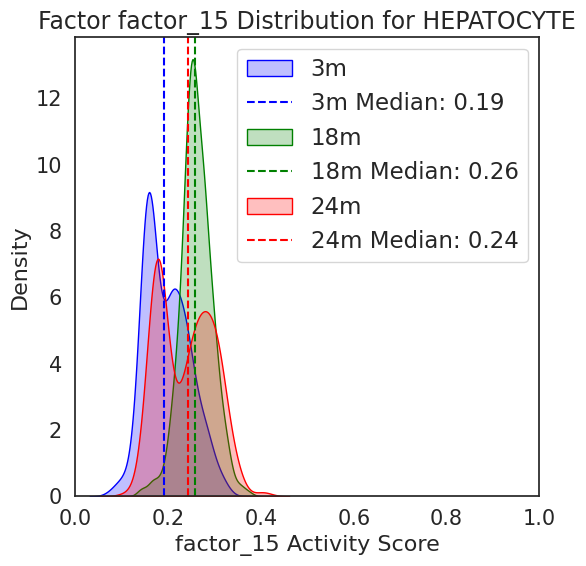

In [26]:
plot_factor_distribution_by_age(splice_adata, "factor_15", "HEPATOCYTE")

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:281: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(scores, label=f"{age}", color=colors[age], shade=True)


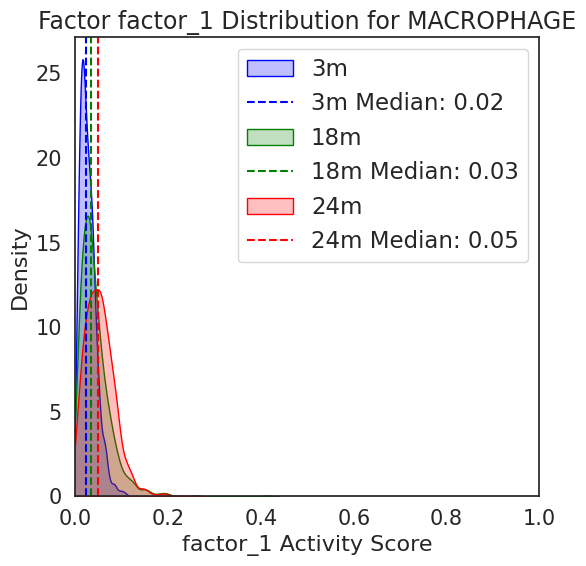

In [27]:
plot_factor_distribution_by_age(splice_adata, "factor_1", "MACROPHAGE")

### Plot factor distribution across all cells in cell type regardless of age 

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:232: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(young_scores, label="Young", color="blue", shade=True)
/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:235: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(old_scores, label="Old", color="red", shade=True)


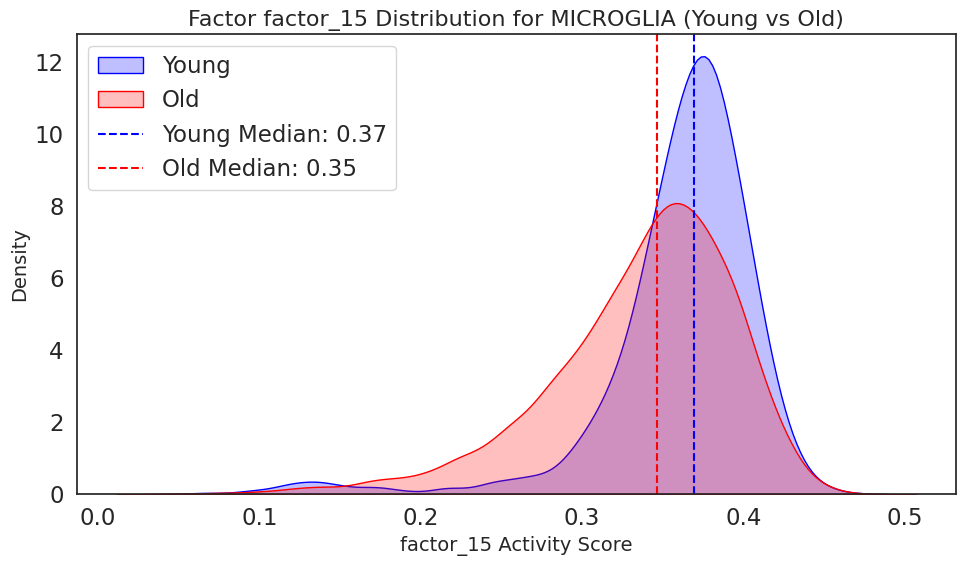

In [28]:
plot_factor_distribution(splice_adata, "MICROGLIA", "factor_15")

In [29]:
# Step 1: Convert age categories to numerical values (3m -> 3, 18m -> 18, 24m -> 24)
age_map = {'3m': 1, '18m': 2, '24m': 3}
splice_adata.obs['age_numeric'] = splice_adata.obs['age'].map(age_map).astype(int)
# Example usage
rmse, coefficients_df = linear_regression_age_prediction(splice_adata, K=30)

Age Prediction RMSE: 0.7088


In [30]:
splice_adata.obs['age_numeric'].values

array([1, 1, 1, ..., 3, 1, 2])

In [31]:
# Sort the DataFrame by coefficient in descending order
coefficients_df = coefficients_df.sort_values(by='Coefficient', ascending=False)

In [32]:
# Select columns that contain "factor" in their name and ensure they are numeric
factor_columns = splice_adata.obs.filter(like='factor')

# Convert the selected factor columns to numeric, if they are not already
for col in factor_columns.columns:
    splice_adata.obs[col] = pd.to_numeric(splice_adata.obs[col], errors='coerce')

# Group by age and calculate the median for these factor columns
age_groups = splice_adata.obs.groupby('age_category')[factor_columns.columns].median()

# Compute the delta between 3m, 18m, and 24m for each factor
deltas = pd.DataFrame({
    'Factor': [f'factor_{i}' for i in range(1, K + 1)],
    'Delta_OY': age_groups.loc['old'] - age_groups.loc['young']
})

coefficients_with_deltas = deltas.merge(coefficients_df)

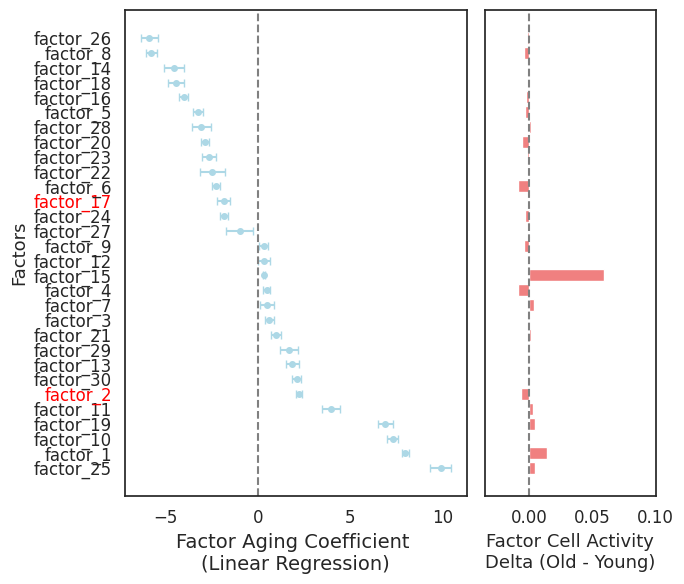

In [33]:
# Set global font size for the entire plot
plt.rcParams.update({'font.size': 12})

# Sort the DataFrame by coefficient in descending order
coefficients_with_deltas = coefficients_with_deltas.sort_values(by='Coefficient', ascending=False)

# Factors to highlight in red
highlight_factors = ['factor_17', 'factor_2']

# Create figure with two subplots (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 6), gridspec_kw={'width_ratios': [2, 1]}, sharey=True)

# Plot 1: Coefficients with error bars using plt.errorbar
ax1.errorbar(coefficients_with_deltas['Coefficient'], coefficients_with_deltas['Factor'],
             xerr=1.96 * coefficients_with_deltas['Standard Error'], fmt='o', capsize=3, markersize=4, color='lightblue')

# Add a vertical line at x = 0 for reference
ax1.axvline(0, color='gray', linestyle='--')

# Set axis labels and title
ax1.set_xlabel('Factor Aging Coefficient \n(Linear Regression)', fontsize=14)
ax1.set_ylabel('Factors', fontsize=13)

# Highlight specific factors in red
y_ticks = ax1.get_yticklabels()
for tick in y_ticks:
    if tick.get_text() in highlight_factors:
        tick.set_color('red')

# Plot 2: Delta (Old - Young) 
ax2.barh(y=coefficients_with_deltas['Factor'], width=coefficients_with_deltas['Delta_OY'], 
         color='lightcoral', label='Delta YO')
ax2.axvline(0, color='gray', linestyle='--')

# Set axis labels and title for delta plot
ax2.set_xlabel('Factor Cell Activity\nDelta (Old - Young)', fontsize=13)
ax2.set_xlim(-0.035, 0.1)

# Adjust font size of tick labels for both axes
ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)

# Adjust layout
plt.tight_layout()

# Save as pdf 
plt.savefig("/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/linear_regression_factors_aging_with_delta.pdf", format='pdf')

# Show the plot
plt.show()

In [34]:
coefficients_with_deltas

,Factor,Delta_OY,Coefficient,Lower CI,Upper CI,Standard Error
24,factor_25,0.004481,9.911939,9.346417,10.477461,0.288534
0,factor_1,0.014092,7.984191,7.788607,8.179775,0.099788
9,factor_10,-0.000323,7.306658,7.005209,7.608107,0.153802
18,factor_19,0.004961,6.903657,6.496906,7.310408,0.207527
10,factor_11,0.002791,3.960820,3.463998,4.457642,0.253482
1,factor_2,-0.006420,2.228694,2.069316,2.388071,0.081316
29,factor_30,-0.000560,2.092053,1.871108,2.312999,0.112728
12,factor_13,0.001106,1.848444,1.498572,2.198316,0.178507
28,factor_29,0.000688,1.683859,1.192163,2.175556,0.250867
20,factor_21,0.001555,0.954828,0.682075,1.227581,0.139161


In [35]:
splice_adata

AnnData object with n_obs × n_vars = 106199 × 80234
    obs: 'cell_id', 'age', 'batch', 'cell_ontology_class', 'method', 'mouse.id', 'sex', 'tissue', 'old_cell_id_index', 'cell_clean', 'cell_id_index', 'subtissue_clean', 'cell_type_grouped', 'factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5', 'factor_6', 'factor_7', 'factor_8', 'factor_9', 'factor_10', 'factor_11', 'factor_12', 'factor_13', 'factor_14', 'factor_15', 'factor_16', 'factor_17', 'factor_18', 'factor_19', 'factor_20', 'factor_21', 'factor_22', 'factor_23', 'factor_24', 'factor_25', 'factor_26', 'factor_27', 'factor_28', 'factor_29', 'factor_30', 'age_category', 'age_numeric'
    var: 'factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5', 'factor_6', 'factor_7', 'factor_8', 'factor_9', 'factor_10', 'factor_11', 'factor_12', 'factor_13', 'factor_14', 'factor_15', 'factor_16', 'factor_17', 'factor_18', 'factor_19', 'factor_20', 'factor_21', 'factor_22', 'factor_23', 'factor_24', 'factor_25', 'factor_26', 'factor_2

In [36]:
# Step 1: Adjust p-values using FDR correction (Benjamini-Hochberg)
# Add FDR-adjusted p-values to the cell_type_df
_, result_table['p_value_fdr'] = fdrcorrection(result_table['p_value'])

# Merge the two tables on the 'Factor' column
merged_df = pd.merge(result_table, coefficients_df, how='inner', left_on='factor', right_on='Factor')
threshold = 2 

# Step 1: Filter for significant factors (e.g., p-value < 0.05)
# Step 3: Filter for significant factors based on FDR-adjusted p-values and absolute delta_median > 0.05
significant_factors = merged_df[
    (merged_df['p_value_fdr'] < 0.05) & 
    (merged_df['delta_median'].abs() > 0.05)
]

# Step 2: Group by factor and summarize the number of cell types where the factor is significantly different
factor_summary = significant_factors.groupby('factor').agg(
    num_significant_cell_types=('cell_type', 'count'),  # Count how many cell types show significant changes
    avg_delta_median=('delta_median', 'mean'),          # Average delta_median across all cell types
    min_delta_median=('delta_median', 'min'),           # Minimum delta_median (enriched in young)
    max_delta_median=('delta_median', 'max'),           # Maximum delta_median (enriched in old)
    avg_coefficient=('Coefficient', 'mean')             # Average age coefficient from linear regression
).reset_index()

# Step 3: Identify factors that are commonly enriched (shared across many cell types)
shared_factors = factor_summary[factor_summary['num_significant_cell_types'] > threshold]  # Set a threshold, e.g., > 5 cell types

# Step 4: Identify factors that are strongly enriched in a subset (i.e., large delta in some cell types)
subset_enriched_factors = factor_summary[factor_summary['num_significant_cell_types'] <= threshold]

# Step 5: Sort the results for better readability
shared_factors = shared_factors.sort_values(by='num_significant_cell_types', ascending=False)
subset_enriched_factors = subset_enriched_factors.sort_values(by='avg_delta_median', ascending=False)

# Display the summary
print("Factors Shared Across Many Cell Types:")
print(shared_factors)

print("\nFactors Strongly Enriched in a Subset of Cell Types:")
print(subset_enriched_factors)

Factors Shared Across Many Cell Types:
Empty DataFrame
Columns: [factor, num_significant_cell_types, avg_delta_median, min_delta_median, max_delta_median, avg_coefficient]
Index: []

Factors Strongly Enriched in a Subset of Cell Types:
      factor  num_significant_cell_types  avg_delta_median  min_delta_median  \
1  factor_20                           1          0.086619          0.086619   
2  factor_30                           1          0.081418          0.081418   
0  factor_15                           2          0.060073          0.057042   

   max_delta_median  avg_coefficient  
1          0.086619        -2.851961  
2          0.081418         2.092053  
0          0.063103         0.340939  


In [37]:
fact20_age = result_table[result_table["factor"] == "factor_20"].sort_values(by="delta_median")
fact15_age = result_table[result_table["factor"] == "factor_15"].sort_values(by="delta_median")
fact30_age = result_table[result_table["factor"] == "factor_30"].sort_values(by="delta_median")
fact2_age = result_table[result_table["factor"] == "factor_2"].sort_values(by="delta_median")
fact14_age = result_table[result_table["factor"] == "factor_14"].sort_values(by="delta_median")
fact26_age = result_table[result_table["factor"] == "factor_26"].sort_values(by="delta_median")

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


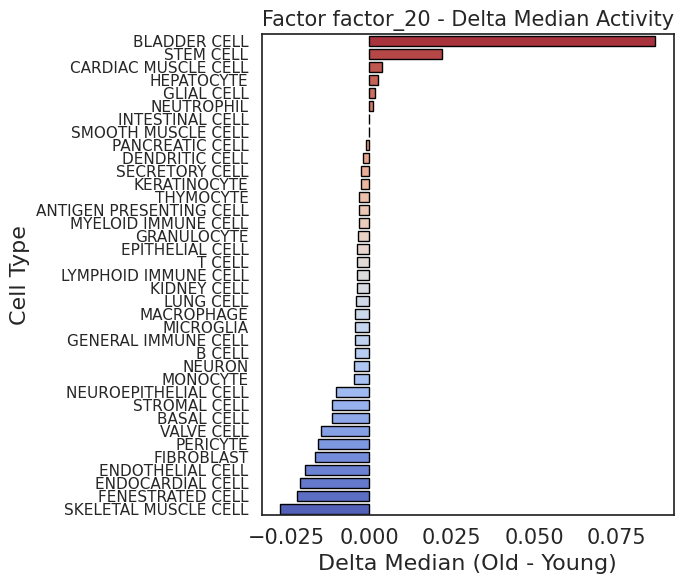

In [38]:
plot_factor_medians(fact20_age, 'factor_20')

/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_utilities.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


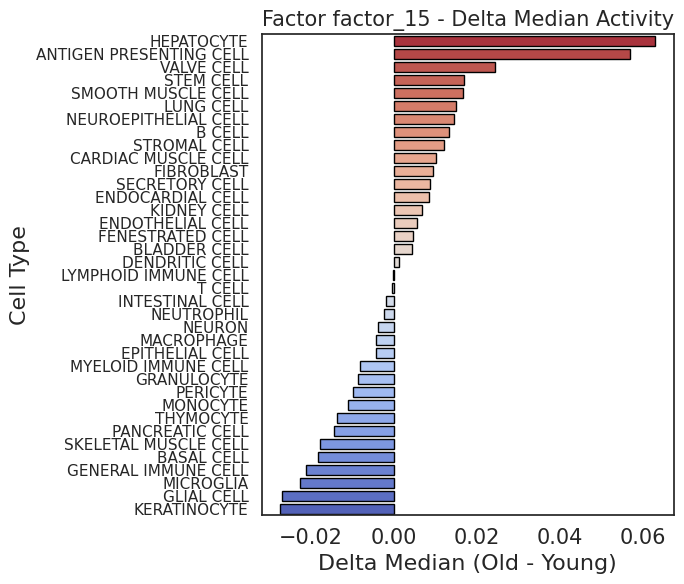

In [39]:
plot_factor_medians(fact15_age, 'factor_15')

In [40]:
# Assuming splice_adata is your AnnData object and the latent factors are stored in `splice_adata.obs`
feature = "cell_type_grouped"
# Call the function
accuracy, coefficients_cell_type = logistic_regression_feature_prediction_simple(splice_adata, feature, K)
# Check the accuracy and coefficients
print(f"Accuracy for {feature}: {accuracy}")
# For each cell type, we will take the top 10 factors by absolute coefficient value.
top_factors_by_cell_type = coefficients_cell_type.apply(lambda x: x.abs().nlargest(5).index.tolist(), axis=1)

Cell_type_grouped Prediction Accuracy: 0.4869
Accuracy for cell_type_grouped: 0.48686440677966103


In [41]:
splice_adata.var_names = splice_adata.var["junction_id"]

### Get UMAP based on assign_post embeddings in splice_data.obs columns with "factor" in them 

In [42]:
# Step 1: Extract the assign_post embeddings from splice_data.obs
# Get all columns with 'factor' in their names
factor_columns = [col for col in splice_adata.obs.columns if 'factor' in col]
embedding = splice_adata.obs[factor_columns].values

# Step 2: Perform UMAP on the factor embeddings
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding = reducer.fit_transform(embedding)
splice_adata.obsm['X_umap'] = umap_embedding

shuffled_indices = np.random.permutation(splice_adata.obs.index)
shuffled_adata = splice_adata[shuffled_indices, :]

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [43]:
atses

,event_id,gene_id,gene_name,num_junctions,event_type,annotation_status,junction_id,chrom,start,end,strand,cells,total_score,splice_motif,donor_seq,acceptor_seq,label_5_prime,label_3_prime,position_off_5_prime,position_off_3_prime
0,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,three_prime,chr1_4774516_4776409_-,chr1,4774516,4776409,-,375,5554,GT-AG,GT,AG,annotated on 5',annotated on 3',-32.0,0.0
1,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,both,chr1_4776801_4777524_-,chr1,4776801,4777524,-,21515,1230743,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0
2,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,three_prime,chr1_4774516_4776405_-,chr1,4774516,4776405,-,32,251,GT-AG,GT,AG,annotated on 5',annotated on 3',-28.0,0.0
3,ATSE_0,ENSMUSG00000033845.13,Mrpl15,4,complex,both,chr1_4774516_4777524_-,chr1,4774516,4777524,-,6612,197883,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0
4,ATSE_1,ENSMUSG00000033845.13,Mrpl15,14,complex,both,chr1_4782301_4782567_-,chr1,4782301,4782567,-,893,33145,GT-AG,GT,AG,annotated on 5',annotated on 3',1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270415,ATSE_54451,ENSMUSG00000099369.1,Gm28838,4,alternative_5_prime,unannotated,chrY_70902970_71081372_+,chrY,70902970,71081372,+,11,130,GT-AG,GT,AG,unannotated on 5',annotated on 3',NaN,99.0
270416,ATSE_54452,ENSMUSG00000095925.1,Defa-ps17,2,alternative_5_prime,unannotated,chr8_21445055_21473237_+,chr8,21445055,21473237,+,20,134,GT-AG,GT,AG,unannotated on 5',annotated on 3',NaN,14.0
270417,ATSE_54452,ENSMUSG00000095925.1,Defa-ps17,2,alternative_5_prime,unannotated,chr8_21315532_21473237_+,chr8,21315532,21473237,+,11,111,GT-AG,GT,AG,unannotated on 5',annotated on 3',NaN,14.0
270418,ATSE_54453,ENSMUSG00000085165.1,Gm12089,2,alternative_5_prime,both,chr11_29515366_29517208_+,chr11,29515366,29517208,+,10,230,GT-AG,GT,AG,annotated on 5',annotated on 3',0.0,1.0


In [44]:
if gtf_used:
    genes_ids = atses[["gene_id", "gene_name"]].drop_duplicates()
    aging_genes = global_aging_genes[global_aging_genes["global_aging_genes"].isin(splice_adata.var["gene_name"])].global_aging_genes.values
    genes_ids['aging_genes'] = genes_ids['gene_name'].isin(combined_genes).map({True: 'yes', False: 'no'})
    genes_ids.aging_genes.value_counts()
    juncs_factors_albf = juncs_factors_albf.merge(genes_ids)

In [45]:
juncs_factors_albf.aging_genes.value_counts()

aging_genes
no     78307
yes     1927
Name: count, dtype: int64

### Look at ALBF scores of junction within a specific factor

### Rerun logistic regression to predict age groups comparing splicing vs gene expression based signals

In [46]:
splice_adata.obs

,cell_id,age,batch,cell_ontology_class,method,mouse.id,sex,tissue,old_cell_id_index,cell_clean,...,factor_23,factor_24,factor_25,factor_26,factor_27,factor_28,factor_29,factor_30,age_category,age_numeric
cell_id_for_index,,,,,,,,,,,,,,,,,,,,,
A1_MAA001875,A1-MAA001875-3_39_F-1-1,3m,1,intestinal crypt stem cell,facs,3_39_F,female,Large_Intestine,0,A1_MAA001875,...,0.072689,0.048323,0.007903,0.078084,0.000992,0.000595,0.005517,0.000397,young,1
A10_MAA000398,A10-MAA000398-3_9_M-1-1,3m,1,T cell,facs,3_9_M,male,Heart,1,A10_MAA000398,...,0.025226,0.104484,0.005192,0.009791,0.001981,0.003500,0.014233,0.003395,young,1
A10_MAA000612,A10-MAA000612-3_9_M-1-1,3m,1,large intestine goblet cell,facs,3_9_M,male,Large_Intestine,2,A10_MAA000612,...,0.024771,0.055599,0.019849,0.020229,0.011631,0.010163,0.017356,0.022236,young,1
A10_B001880,A10_B001880_S214_L002,24m,1,epithelial cell,facs,24_61_M,male,BAT,3,A10_B001880,...,0.017207,0.013076,0.021714,0.003099,0.003594,0.005698,0.019814,0.005697,old,3
A11_MAA000926,A11-MAA000926-3_9_M-1-1,3m,1,endothelial cell,facs,3_9_M,male,Brain_Non-Myeloid,4,A11_MAA000926,...,0.013082,0.026388,0.008514,0.012327,0.003917,0.002711,0.007931,0.011571,young,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P8_MAA001865,P8-MAA001865-3_38_F-1-1,3m,1,T cell,facs,3_38_F,female,Trachea,106194,P8_MAA001865,...,0.025871,0.111745,0.010399,0.014921,0.001086,0.002455,0.004346,0.002809,young,1
P8_B000505,P8_B000505_B008435_S368,18m,1,mesenchymal stem cell of adipose,facs,18_45_M,male,GAT,106195,P8_B000505,...,0.005046,0.022340,0.012138,0.008104,0.004506,0.004194,0.011247,0.102390,old,2
P8_B002982,P8_B002982_S80_L004,24m,1,bronchial smooth muscle cell,facs,24_60_M,male,Lung,106196,P8_B002982,...,0.008538,0.021756,0.012774,0.018320,0.002337,0.003857,0.026651,0.002970,old,3


In [47]:
# Assume splice_adata and gene_expression_adata are already loaded and preprocessed
feature_to_predict = 'age'  # Replace target feature

accuracies, aurocs, auprs, models, label_encoder, coefficients_dfs = logistic_regression_feature_prediction(
    splice_adata,
    adata,
    feature=feature_to_predict,
    K=K,
    n_pcs=50,
    test_size=0.2,
    random_state=42
)

print(accuracies)

Age Prediction Accuracy using Splicing Factors: 0.5727
Age Prediction AUROC using Splicing Factors: 0.7577
Age Prediction AUPR using Splicing Factors: 0.6010
Age Prediction Accuracy using Gene Expression PCs: 0.6226
Age Prediction AUROC using Gene Expression PCs: 0.7988
Age Prediction AUPR using Gene Expression PCs: 0.6550
Age Prediction Accuracy using Combined Features: 0.6742
Age Prediction AUROC using Combined Features: 0.8446
Age Prediction AUPR using Combined Features: 0.7268
Age Prediction Accuracy using Tissue Only: 0.4183
Age Prediction AUROC using Tissue Only: 0.5970
Age Prediction AUPR using Tissue Only: 0.4076
{'splicing': 0.5727401129943502, 'gene_expression': 0.6225988700564972, 'combined': 0.6741996233521658, 'tissue_only': 0.41826741996233524}


In [48]:
coef_splicing = coefficients_dfs['splicing']
coef_gene_expression = coefficients_dfs['gene_expression']
coef_combined = coefficients_dfs['combined']
coef_tissue_only = coefficients_dfs['tissue_only']

### Calcualte Entropy and Perplexity across Cells

Entropy and Perplexity for each cell (first 10 cells):
[[ 2.6027162  13.50035791]
 [ 2.42440851 11.29554626]
 [ 3.18601816 24.19190712]
 [ 2.87482767 17.72236976]
 [ 2.67294687 14.48258462]
 [ 2.53082147 12.56382269]
 [ 2.80152334 16.4697166 ]
 [ 2.51670142 12.38766753]
 [ 2.63344662 13.92167001]
 [ 2.56810635 13.0411058 ]]


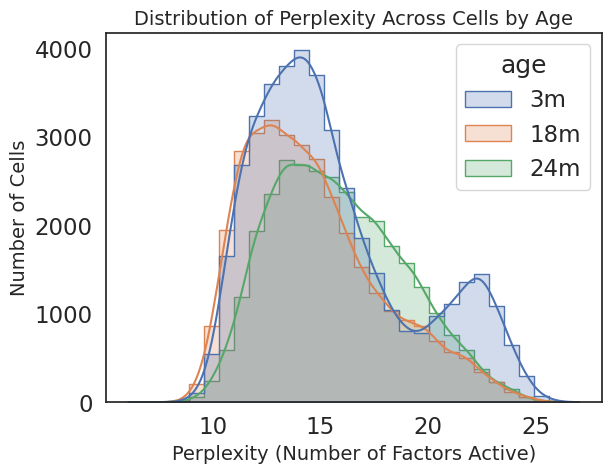

In [49]:
# Calculate entropy for each cell (each row sums to 1)
entropy = -np.sum(assign_post * np.log(assign_post + 1e-12), axis=1)  # Small epsilon added for numerical stability

# Calculate perplexity for each cell
perplexity = np.exp(entropy)

# Combine results for better readability
results = np.column_stack((entropy, perplexity))

# Display the first few results
print("Entropy and Perplexity for each cell (first 10 cells):")
print(results[:10])

splice_adata.obs["perplexity"] = perplexity
splice_adata.obs["entropy"] = entropy

# Assuming `perplexity` is already added to `splice_adata.obs` as a column
sns.histplot(data=splice_adata.obs, x="perplexity", hue="age", bins=30, kde=True, element="step")
plt.xlabel("Perplexity (Number of Factors Active)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Perplexity Across Cells by Age", fontsize=14)
plt.show()

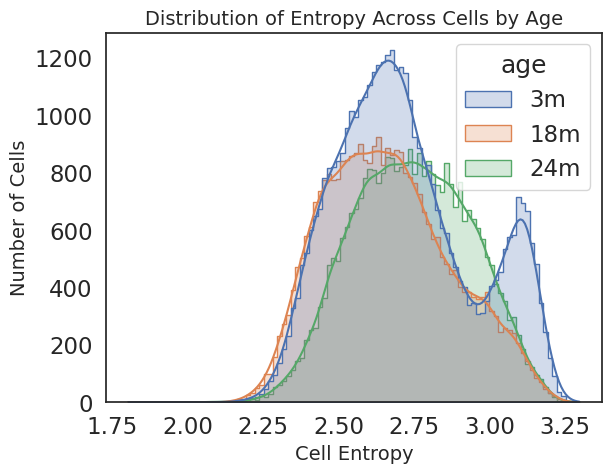

In [50]:
# Assuming `perplexity` is already added to `splice_adata.obs` as a column
sns.histplot(data=splice_adata.obs, x="entropy", hue="age", bins=100, kde=True, element="step")
plt.xlabel("Cell Entropy", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Entropy Across Cells by Age", fontsize=14)
plt.show()

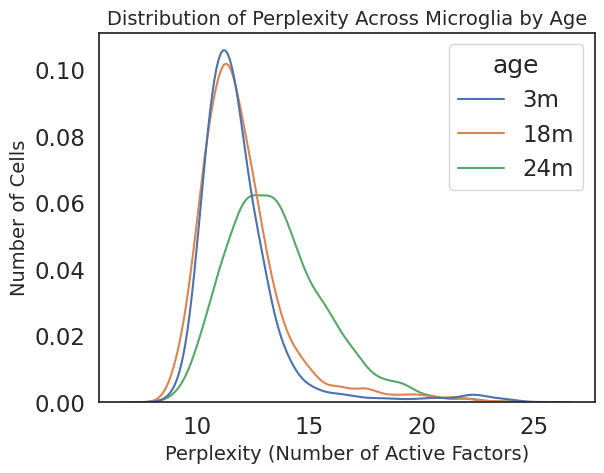

In [51]:
microglia_only = splice_adata.obs[splice_adata.obs["cell_type_grouped"] == "MICROGLIA"]
sns.kdeplot(data=microglia_only, x="perplexity", hue="age")
plt.xlabel("Perplexity (Number of Active Factors)", fontsize=14)
plt.ylabel("Number of Cells", fontsize=14)
plt.title("Distribution of Perplexity Across Microglia by Age", fontsize=14)
plt.show()

/scratch/ipykernel_2355895/2709389559.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_perplexity = splice_adata.obs.groupby(['cell_type_grouped', 'age'])['perplexity'].median().unstack()


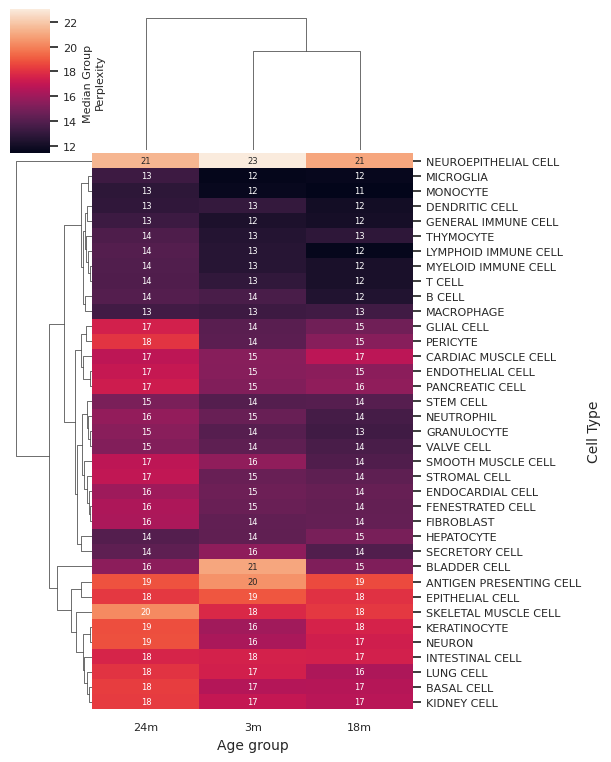

In [52]:
# Calculate median perplexity for each cell type and age category
median_perplexity = splice_adata.obs.groupby(['cell_type_grouped', 'age'])['perplexity'].median().unstack()

# Make font size for ERVERYTHING smaller!
g = sns.clustermap(median_perplexity, xticklabels=1, yticklabels=1, 
               annot_kws={"size": 6},  # Smaller font size for annotations
               annot=True, figsize=(8, 8), 
               cbar_kws={'label': 'Median Group \nPerplexity'})

# Set font size for row and column tick labels
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0, fontsize=8)
plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), fontsize=8)

# Customize the color legend font size
g.cax.yaxis.label.set_size(8)
g.cax.tick_params(labelsize=8)

# Set axis labels with smaller font size
g.ax_heatmap.set_xlabel("Age group", fontsize=10)
g.ax_heatmap.set_ylabel("Cell Type", fontsize=10)

plt.show()

### Some of these cell types are very broad like "Lung cell", "Bladder cell", "Kidney cell" some can still have immune cells in them?

### Calcualte Entropy and Perplexity across Junctions!

In [53]:
# remove index names from splice_adata.var 
splice_adata.var = splice_adata.var.reset_index(drop=True)

In [54]:
# Calculate entropy for each junction (columns represent factors for each junction)
entropy = -np.sum(psi_learned.T * np.log(psi_learned.T + 1e-12), axis=1)

# Calculate perplexity for each junction
perplexity = np.exp(entropy)

# Combine results for better readability
results = np.column_stack((entropy, perplexity))

# Make into dataframe with columns junction_entropt and junction_perplexity
junc_results = pd.DataFrame(results, columns=["junction_entropy", "junction_perplexity"])
junc_results["junction_id"] = splice_adata.var["junction_id"]
junc_results.sort_values(by="junction_perplexity", ascending=False, inplace=True)
junc_results

,junction_entropy,junction_perplexity,junction_id
27461,11.026675,61492.785316,chr17_57236423_57236696_-
37682,11.022606,61243.090405,chr1_93785966_93786510_+
63862,11.016707,60882.834324,chr7_126786291_126786371_-
68015,11.010592,60511.687070,chr7_66079789_66080331_+
27459,11.009557,60449.097559,chr17_57236239_57236373_-
...,...,...,...
45196,0.040019,1.040830,chr3_130728851_130729228_-
47575,0.039661,1.040458,chr3_90213044_90213235_-
78174,0.038444,1.039193,chrX_102185660_102187983_-
29675,0.038035,1.038767,chr18_60774686_60776417_+


In [55]:
splice_adata.var = splice_adata.var.merge(junc_results, on="junction_id")

In [56]:
splice_adata.var

,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,...,position_off_3_prime,CountJuncs,old_junction_id_index,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score,junction_entropy,junction_perplexity
0,0.006633,0.000204,0.007265,0.000621,0.001901,0.000187,0.001092,0.000783,0.000461,0.000455,...,NaN,132,0,19,0.000179,1.0,0.0,1,0.566029,1.761258
1,0.036358,0.944021,0.059155,0.065750,0.025275,0.860227,0.068748,0.073449,0.489904,0.484563,...,1.0,191547,1,5625,0.052967,2.0,1.5,1,5.368600,214.562196
2,0.003183,0.000483,0.002251,0.001276,0.002377,0.000693,0.002154,0.001119,0.001319,0.006723,...,1.0,370,2,26,0.000245,2.0,0.0,1,0.548813,1.731196
3,0.002385,0.000235,0.002854,0.001843,0.004524,0.000307,0.000592,0.000448,0.000639,0.003967,...,1.0,266,3,18,0.000169,2.0,0.0,1,0.561839,1.753894
4,0.014021,0.004285,0.028612,0.009046,0.020724,0.003570,0.001376,0.004360,0.008347,0.005093,...,1.0,3734,4,200,0.001883,2.0,0.0,1,1.662476,5.272347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80229,0.006110,0.001312,0.004919,0.005075,0.002085,0.006987,0.001625,0.008160,0.003844,0.001720,...,3.0,278,270323,25,0.000235,1.0,0.0,1,0.833772,2.301986
80230,0.057891,0.732102,0.440429,0.583275,0.217548,0.296316,0.062368,0.891899,0.373169,0.189371,...,0.0,82903,270324,3287,0.030951,2.0,1.5,1,6.790344,889.218968
80231,0.007909,0.001166,0.004331,0.006251,0.004807,0.002433,0.003893,0.003897,0.002462,0.005984,...,0.0,759,270325,49,0.000461,2.0,0.0,1,1.190153,3.287583
80232,0.064044,0.146668,0.063470,0.240971,0.078250,0.780660,0.123018,0.112253,0.149000,0.763514,...,1.0,34257,270352,1954,0.018399,2.0,1.5,1,6.509600,671.558072


In [ ]:
# drop these columns from splice_adat.var junction_entropy_x	junction_perplexity_x	junction_entropy_y	junction_perplexity_y
# splice_adata.var = splice_adata.var.drop(columns=["junction_entropy_x", "junction_perplexity_x", "junction_entropy_y", "junction_perplexity_y"])

In [58]:
splice_adata.var.sort_values(by="junction_id_index", ascending=False, inplace=True)
splice_adata.var.sort_values(by="junction_perplexity", ascending=True, inplace=False)

,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,factor_10,...,position_off_3_prime,CountJuncs,old_junction_id_index,non_zero_count_cells,non_zero_cell_prop,annotation_status_score,non_zero_cell_prop_score,splice_motif_score,junction_entropy,junction_perplexity
76913,0.000118,0.000049,0.000144,0.000164,0.000184,0.000072,0.000078,0.000108,0.000081,0.000240,...,1.0,551,259593,25,0.000235,2.0,0.0,1,0.037567,1.038281
29675,0.000046,0.000043,0.000106,0.000165,0.000136,0.000054,0.000037,0.000050,0.000201,0.000121,...,-16.0,176,101536,14,0.000132,1.0,0.0,1,0.038035,1.038767
78174,0.000171,0.000060,0.000150,0.000080,0.000230,0.000053,0.000047,0.000113,0.000057,0.000100,...,0.0,392,263701,10,0.000094,1.0,0.0,1,0.038444,1.039193
47575,0.000274,0.000039,0.000149,0.000067,0.000129,0.000062,0.000087,0.000084,0.000089,0.000049,...,0.0,220,161321,11,0.000104,1.0,0.0,1,0.039661,1.040458
45196,0.000254,0.000043,0.000232,0.000133,0.000134,0.000130,0.000029,0.000103,0.000086,0.000081,...,0.0,213,153875,15,0.000141,2.0,0.0,1,0.040019,1.040830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27459,0.383808,0.403285,0.385412,0.384785,0.375450,0.385736,0.381126,0.378956,0.364803,0.396675,...,0.0,1380838,94730,23578,0.222017,2.0,1.5,1,11.009557,60449.097559
68015,0.396309,0.373252,0.395042,0.397030,0.401905,0.392791,0.389625,0.373298,0.404893,0.387301,...,1.0,1816570,229112,39841,0.375154,2.0,1.5,1,11.010592,60511.687070
63862,0.392081,0.386060,0.393424,0.383825,0.381149,0.401445,0.388296,0.386580,0.377963,0.398064,...,0.0,2640333,215113,42966,0.404580,2.0,1.5,1,11.016707,60882.834324
37682,0.367767,0.360362,0.355921,0.350830,0.355218,0.407928,0.350794,0.334201,0.364417,0.356817,...,1.0,903953,128976,16723,0.157469,2.0,1.5,1,11.022606,61243.090405


### Calcualte Entropy and Perplexity across Factors to see how many cell types they are active in ?

### Look at factor-factor correlations in terms of cell usage - also do this usage junction PSI

In [59]:
splice_adata.obs[factor_columns].shape

(106199, 30)

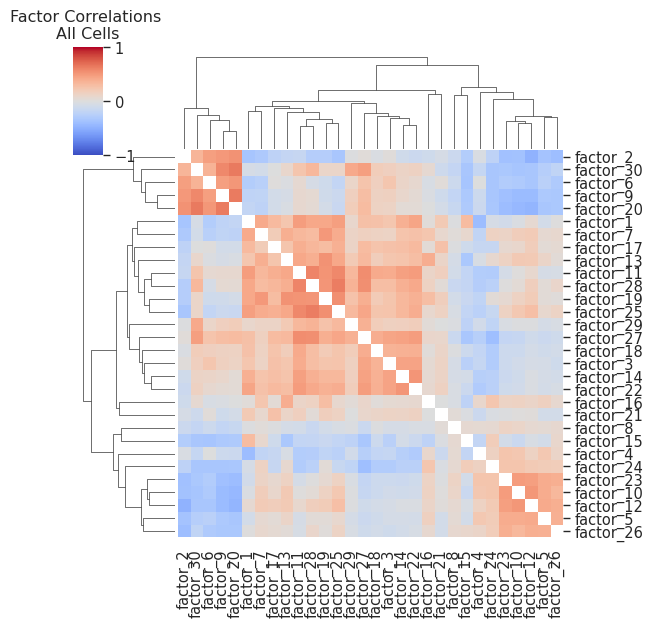

In [60]:
factor_corr_spearman_all = splice_adata.obs[factor_columns].corr(method='spearman')

# Create a mask to hide the diagonal
mask = np.eye(len(factor_corr_spearman_all), dtype=bool)

# Set overall font size smaller using Seaborn context
sns.set_context("paper", font_scale=1.2)  # Adjust `font_scale` for smaller/larger font

# Create a clustermap with masked diagonal
g = sns.clustermap(
    factor_corr_spearman_all, annot=False, cmap='coolwarm', center=0, mask=mask,
    yticklabels=1, xticklabels=1, figsize=(6, 6), vmin=-1, vmax=1)

plt.title("Factor Correlations \nAll Cells")
plt.show()

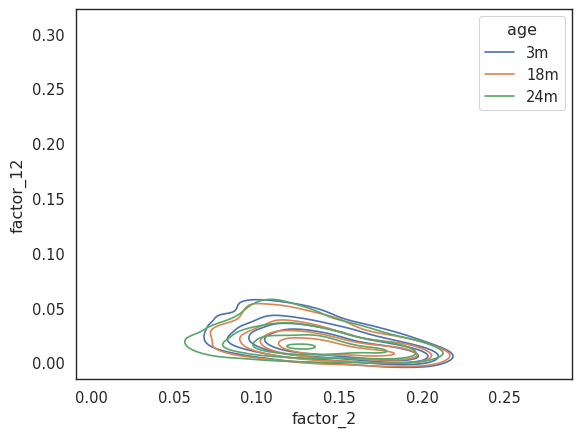

In [61]:
# let's look at correlation of cells activities among factor_1 and factor_13 
# make a scatter plot of factor_1 vs factor_13

# Plot scatterplot with density visualization
sns.kdeplot(
    data=splice_adata.obs.sample(10000),
    x="factor_2",
    y="factor_12",
    levels=5, thresh=.2,
    hue="age")
plt.show()

### Look at factor-factor correlations using junction PSI values...

In [62]:
psi_learned_df = pd.DataFrame(psi_learned).T
psi_learned_df.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.006633,0.000204,0.007265,0.000621,0.001901,0.000187,0.001092,0.000783,0.000461,0.000455,...,0.001641,0.039003,0.000968,0.000481,0.005337,0.000979,0.005606,0.010442,0.002777,0.001043
1,0.036358,0.944021,0.059155,0.065750,0.025275,0.860227,0.068748,0.073449,0.489904,0.484563,...,0.072946,0.061327,0.988568,0.128969,0.041692,0.915580,0.050269,0.029630,0.024940,0.364111
2,0.003183,0.000483,0.002251,0.001276,0.002377,0.000693,0.002154,0.001119,0.001319,0.006723,...,0.001269,0.011300,0.004736,0.001071,0.001160,0.001999,0.013725,0.003611,0.006994,0.002516
3,0.002385,0.000235,0.002854,0.001843,0.004524,0.000307,0.000592,0.000448,0.000639,0.003967,...,0.000410,0.041320,0.001647,0.000916,0.009002,0.001733,0.007750,0.010990,0.001827,0.003282
4,0.014021,0.004285,0.028612,0.009046,0.020724,0.003570,0.001376,0.004360,0.008347,0.005093,...,0.007714,0.044046,0.008630,0.005676,0.002346,0.013526,0.011167,0.018950,0.016754,0.005924


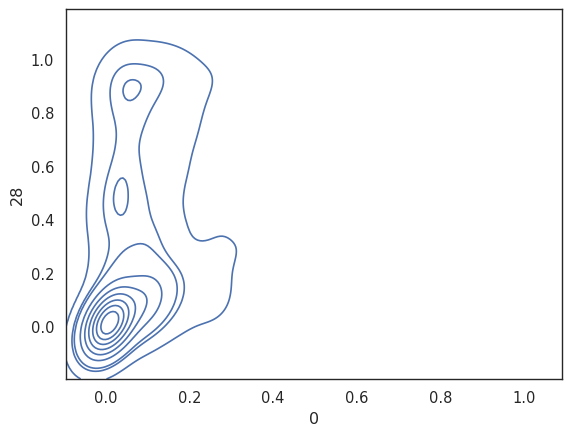

In [63]:
sns.kdeplot(
    data=psi_learned_df.sample(5000),x=0, y=28)
plt.show()

In [64]:
factor_corr_spearman_juncs = psi_learned_df.corr(method='spearman')

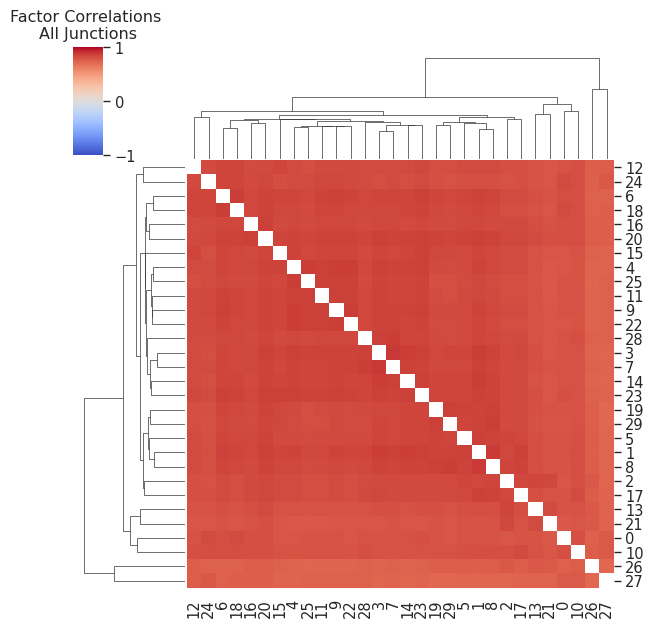

In [65]:
# Create a mask to hide the diagonal
mask = np.eye(len(factor_corr_spearman_juncs), dtype=bool)

# Set overall font size smaller using Seaborn context
sns.set_context("paper", font_scale=1.2)  # Adjust `font_scale` for smaller/larger font

# Create a clustermap with masked diagonal
g = sns.clustermap(
    factor_corr_spearman_juncs, annot=False, cmap='coolwarm', center=0, mask=mask,
    yticklabels=1, xticklabels=1, figsize=(6, 6), vmin=-1, vmax=1)

plt.title("Factor Correlations \nAll Junctions")
plt.show()

### Look at junction annotations!

In [67]:
juncs_factors_albf

,junction_id,gene_id,gene_name,annotation_status,event_id,junction_id_index,cell_state_0,cell_state_1,cell_state_2,cell_state_3,...,loc_25,mu_26,loc_26,mu_27,loc_27,mu_28,loc_28,mu_29,loc_29,aging_genes
0,chr10_100016035_100021457_+,ENSMUSG00000019966.18,Kitl,five_prime,ATSE_23615,0,0.006633,0.000204,0.007265,0.000621,...,1.567685,-5.478811,1.493076,-5.811129,1.553652,-7.116404,1.552899,-7.619374,1.500010,no
1,chr10_100016035_100051845_+,ENSMUSG00000019966.18,Kitl,both,ATSE_23615,1,0.036358,0.944021,0.059155,0.065750,...,0.162336,-4.194407,1.784892,-4.193735,1.822587,-3.415251,1.313002,-0.575690,0.110722,no
2,chr10_100016035_100064083_+,ENSMUSG00000019966.18,Kitl,both,ATSE_23615,2,0.003183,0.000483,0.002251,0.001276,...,1.394887,-5.591173,1.597392,-6.050131,1.565317,-7.133252,1.743533,-6.757833,1.269683,no
3,chr10_100016035_100087346_+,ENSMUSG00000019966.18,Kitl,both,ATSE_23615,3,0.002385,0.000235,0.002854,0.001843,...,1.611146,-5.147545,1.440011,-6.373848,1.648467,-7.337908,1.475843,-7.017733,1.316903,no
4,chr10_100016155_100051845_+,ENSMUSG00000019966.18,Kitl,both,ATSE_23615,4,0.014021,0.004285,0.028612,0.009046,...,0.685878,-4.810602,1.515853,-5.128892,1.511706,-5.786237,1.439034,-5.723966,1.262025,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80229,chrY_1282945_1284321_-,ENSMUSG00000069045.11,Ddx3y,five_prime,ATSE_34839,80229,0.006110,0.001312,0.004919,0.005075,...,1.536462,-5.237841,1.534962,-5.383015,1.613794,-5.788379,1.209756,-5.561657,1.345173,no
80230,chrY_1282948_1284321_-,ENSMUSG00000069045.11,Ddx3y,both,ATSE_34839,80230,0.057891,0.732102,0.440429,0.583275,...,2.081456,-3.994920,1.995622,-3.886954,2.042129,1.651999,0.194091,-4.884007,1.347878,no
80231,chrY_1282968_1284321_-,ENSMUSG00000069045.11,Ddx3y,both,ATSE_34839,80231,0.007909,0.001166,0.004331,0.006251,...,1.595454,-5.109137,1.573730,-4.613352,1.467177,-5.251687,1.254300,-5.944949,1.081962,no
80232,chrY_90762286_90763136_+,ENSMUSG00000095134.2,Mid1-ps1,both,ATSE_42707,80232,0.064044,0.146668,0.063470,0.240971,...,0.065638,0.850348,0.195879,-4.201911,1.546195,-2.692760,1.452141,1.284274,0.142798,no


In [68]:
# junction_id  Cluster  usage_ratio
splice_adata_var = juncs_factors_albf[["junction_id", "event_id"]].drop_duplicates()
splice_adata_var["usage_ratio"] = 0

# Convert junction_ids
splice_junctions = ja.convert_junction_ids(splice_adata_var)

In [ ]:
# higher junction perplexity means that the junction is more complex and is regulated by more factors.s
# lower junction perplexity means that the junction is less complex and is regulated by fewer factors.

In [75]:
# now let's find top 25% of junctions with highest ALBF scores for each factor order by decresing ALBF scores and inccreasing junction perplexity scores
top_10_percent = int(0.25 * len(splice_adata.var))

# Get percent of top junctions that are annotated (both sides) vs (vs one side) vs unannotated for each factor
junc_anno_factors = {}
factor_columns

for factor in factor_columns:
    # sort by factor and junction perplexity
    top_junctions = splice_adata.var.sort_values(by=[factor, "junction_perplexity"], ascending=[False, True]).head(top_10_percent)
    junc_anno_factors[factor] = top_junctions.annotation_status.value_counts()
    
# convert to dataframe
junc_anno_factors_df = pd.DataFrame(junc_anno_factors).T

# get the percentage of annotated junctions for each factor 
junc_anno_factors_df["annotated_percent"] = junc_anno_factors_df["both"] / top_10_percent * 100
# get the percentage of unannotated junctions for each factor
junc_anno_factors_df["unannotated_percent"] = junc_anno_factors_df["unannotated"] / top_10_percent * 100
# get the percentage of junctions annotated on one side for each factor
junc_anno_factors_df["one_side_percent"] =( junc_anno_factors_df["five_prime"] + junc_anno_factors_df["three_prime"] )/ top_10_percent * 100

In [76]:
junc_anno_factors_df

annotation_status,both,five_prime,three_prime,unannotated,annotated_percent,unannotated_percent,one_side_percent
factor_1,19826,136,96,0,98.843354,0.0,1.156646
factor_2,19955,61,42,0,99.486489,0.0,0.513511
factor_3,19914,81,63,0,99.282082,0.0,0.717918
factor_4,19945,66,47,0,99.436634,0.0,0.563366
factor_5,19906,97,55,0,99.242198,0.0,0.757802
factor_6,19925,83,50,0,99.336923,0.0,0.663077
factor_7,19949,81,28,0,99.456576,0.0,0.543424
factor_8,19897,98,63,0,99.197328,0.0,0.802672
factor_9,19940,64,54,0,99.411706,0.0,0.588294
factor_10,19915,92,51,0,99.287068,0.0,0.712932


In [77]:
# keep just the columns that have "factor" in them and melt the table 
coef_splicing_df = coef_splicing.filter(like="factor").reset_index().melt(id_vars="index", var_name="factor", value_name="count")
# rename columns to age group, factor and coefficient 
coef_splicing_df.columns = ["age_group", "factor", "coefficient"]
# sort by absolute coefficient value
coef_splicing_df = coef_splicing_df.sort_values(by="coefficient", ascending=False)
coef_splicing_df

,age_group,factor,coefficient
1,24m,factor_1,16.541529
73,24m,factor_25,14.973580
28,24m,factor_10,14.053719
55,24m,factor_19,11.625341
23,3m,factor_8,10.404839
...,...,...,...
46,24m,factor_16,-9.717013
76,24m,factor_26,-10.229708
29,3m,factor_10,-10.467645
74,3m,factor_25,-12.938834


In [78]:
# let's extract junction_id and perxplecity from splice_adata.var and merge with juncs_factors_albf
splice_adata_var = splice_adata.var[["junction_id", "junction_perplexity"]].drop_duplicates()
juncs_factors_albf = juncs_factors_albf.merge(splice_adata_var, on="junction_id")

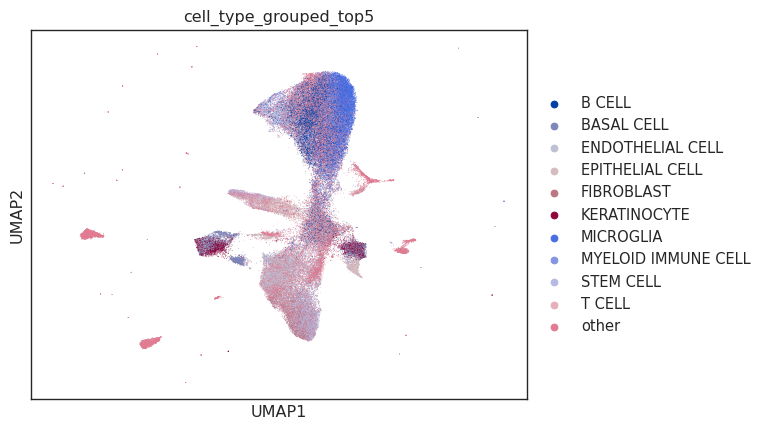

In [84]:
# let's find top 5 cell_types and label them and all other cells make grey 
top_5_cell_types = splice_adata.obs["cell_type_grouped"].value_counts().head(10).index.values

# create a new column in splice_adata.obs called "cell_type_grouped_top5" and label the top 5 cell types and all other cell types as "other"
splice_adata.obs["cell_type_grouped_top5"] = splice_adata.obs["cell_type_grouped"].apply(lambda x: x if x in top_5_cell_types else "other")

# make umap plot with cell_type_grouped_top5 as color
sc.pl.umap(splice_adata, color=["cell_type_grouped_top5"])

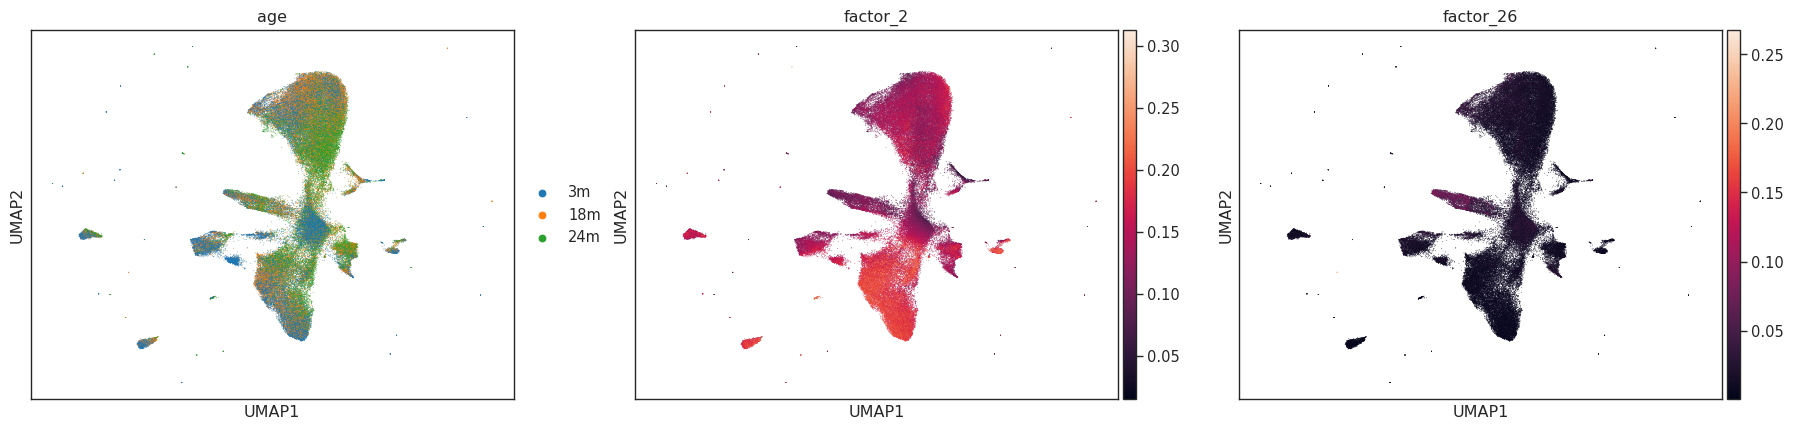

In [82]:
sc.pl.umap(splice_adata, color=["age", "factor_2", "factor_26"])

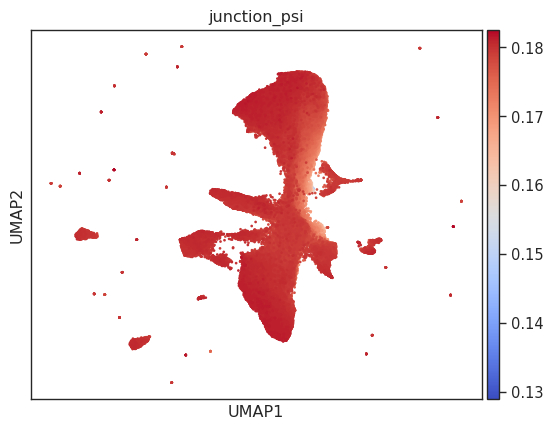

In [83]:
junction_id_index = 35300  
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

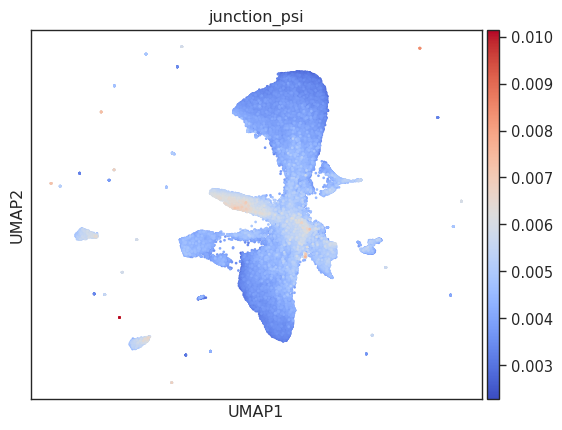

In [85]:
junction_id_index = 26682  
splice_adata.obs['junction_psi'] = splice_adata.layers['new_junc_ratio'][:, junction_id_index].flatten()

# Step 2: Plot UMAP with junction usage ratio
sc.pl.umap(splice_adata, color=['junction_psi'], color_map='coolwarm', size=15)

In [86]:
coefficients_with_deltas.head()

,Factor,Delta_OY,Coefficient,Lower CI,Upper CI,Standard Error
24,factor_25,0.004481,9.911939,9.346417,10.477461,0.288534
0,factor_1,0.014092,7.984191,7.788607,8.179775,0.099788
9,factor_10,-0.000323,7.306658,7.005209,7.608107,0.153802
18,factor_19,0.004961,6.903657,6.496906,7.310408,0.207527
10,factor_11,0.002791,3.960820,3.463998,4.457642,0.253482


In [88]:
# rename annotation column to "Factor" and merge with coefficients_with_deltas
junc_anno_factors_df["Factor"] = junc_anno_factors_df.index
junc_anno_factors_df = junc_anno_factors_df.merge(coefficients_with_deltas, on="Factor")
junc_anno_factors_df

,both,five_prime,three_prime,unannotated,annotated_percent,unannotated_percent,one_side_percent,Factor,Delta_OY,Coefficient,Lower CI,Upper CI,Standard Error
0,19826,136,96,0,98.843354,0.0,1.156646,factor_1,0.014092,7.984191,7.788607,8.179775,0.099788
1,19955,61,42,0,99.486489,0.0,0.513511,factor_2,-0.006420,2.228694,2.069316,2.388071,0.081316
2,19914,81,63,0,99.282082,0.0,0.717918,factor_3,-0.000035,0.624149,0.358555,0.889742,0.135508
3,19945,66,47,0,99.436634,0.0,0.563366,factor_4,-0.008603,0.468907,0.273513,0.664301,0.099692
4,19906,97,55,0,99.242198,0.0,0.757802,factor_5,-0.003525,-3.249971,-3.505922,-2.994019,0.130589
5,19925,83,50,0,99.336923,0.0,0.663077,factor_6,-0.008523,-2.297258,-2.511397,-2.083119,0.109255
6,19949,81,28,0,99.456576,0.0,0.543424,factor_7,0.003933,0.490079,0.130668,0.849491,0.183375
7,19897,98,63,0,99.197328,0.0,0.802672,factor_8,-0.003738,-5.781829,-6.068104,-5.495555,0.146059
8,19940,64,54,0,99.411706,0.0,0.588294,factor_9,-0.004107,0.301875,0.049705,0.554045,0.128659
9,19915,92,51,0,99.287068,0.0,0.712932,factor_10,-0.000323,7.306658,7.005209,7.608107,0.153802


In [89]:
# let's get the top 5 aging related factors using first Delta_OY and then Coefficient
top_aging_factors = junc_anno_factors_df.sort_values(by="Delta_OY", ascending=False).head(5)["Factor"].values
# make new column in junc_anno_factors_df to label factors as "Aging_related"
junc_anno_factors_df["Aging_related"] = "yes"
# keep yes only for Factors in top_aging_factors
junc_anno_factors_df.loc[~junc_anno_factors_df["Factor"].isin(top_aging_factors), "Aging_related"] = "no"
junc_anno_factors_df

,both,five_prime,three_prime,unannotated,annotated_percent,unannotated_percent,one_side_percent,Factor,Delta_OY,Coefficient,Lower CI,Upper CI,Standard Error,Aging_related
0,19826,136,96,0,98.843354,0.0,1.156646,factor_1,0.014092,7.984191,7.788607,8.179775,0.099788,yes
1,19955,61,42,0,99.486489,0.0,0.513511,factor_2,-0.006420,2.228694,2.069316,2.388071,0.081316,no
2,19914,81,63,0,99.282082,0.0,0.717918,factor_3,-0.000035,0.624149,0.358555,0.889742,0.135508,no
3,19945,66,47,0,99.436634,0.0,0.563366,factor_4,-0.008603,0.468907,0.273513,0.664301,0.099692,no
4,19906,97,55,0,99.242198,0.0,0.757802,factor_5,-0.003525,-3.249971,-3.505922,-2.994019,0.130589,no
5,19925,83,50,0,99.336923,0.0,0.663077,factor_6,-0.008523,-2.297258,-2.511397,-2.083119,0.109255,no
6,19949,81,28,0,99.456576,0.0,0.543424,factor_7,0.003933,0.490079,0.130668,0.849491,0.183375,yes
7,19897,98,63,0,99.197328,0.0,0.802672,factor_8,-0.003738,-5.781829,-6.068104,-5.495555,0.146059,no
8,19940,64,54,0,99.411706,0.0,0.588294,factor_9,-0.004107,0.301875,0.049705,0.554045,0.128659,no
9,19915,92,51,0,99.287068,0.0,0.712932,factor_10,-0.000323,7.306658,7.005209,7.608107,0.153802,no


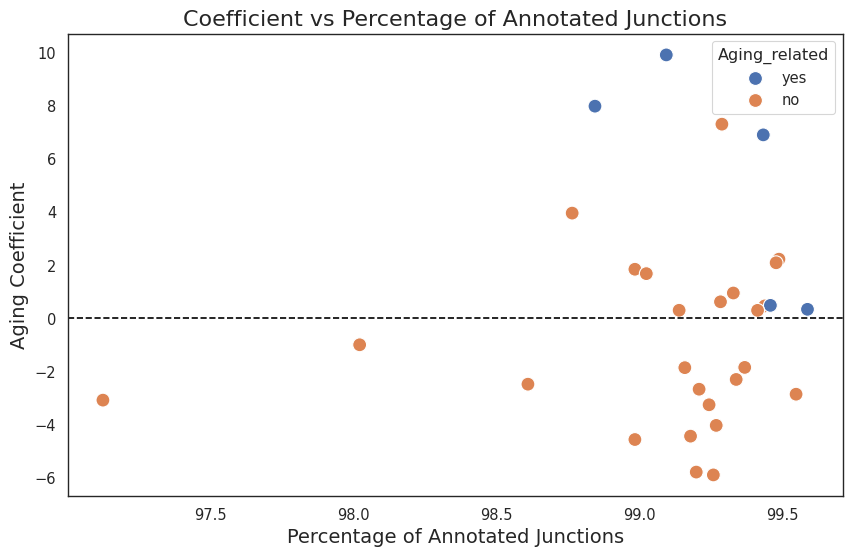

In [99]:
# let's plot coefficient vs annotated percentage for each factor
plt.figure(figsize=(10, 6))
sns.scatterplot(data=junc_anno_factors_df, x="annotated_percent", y="Coefficient",s=100, hue="Aging_related")
plt.xlabel("Percentage of Annotated Junctions", fontsize=14)
plt.ylabel("Aging Coefficient", fontsize=14)
plt.title("Coefficient vs Percentage of Annotated Junctions", fontsize=16)
# Draw horizontal line at 0 
plt.axhline(0, color='black', linestyle='--')

In [102]:
splice_adata.var["annotation_status"].value_counts()

annotation_status
both           60945
five_prime     11587
three_prime     7669
unannotated       33
Name: count, dtype: int64

Text(0.5, 1.0, 'Delta_OY\t vs Percentage of Annotated Junctions')

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 9 (	) missing from current font.
  func(*args, **kwargs)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


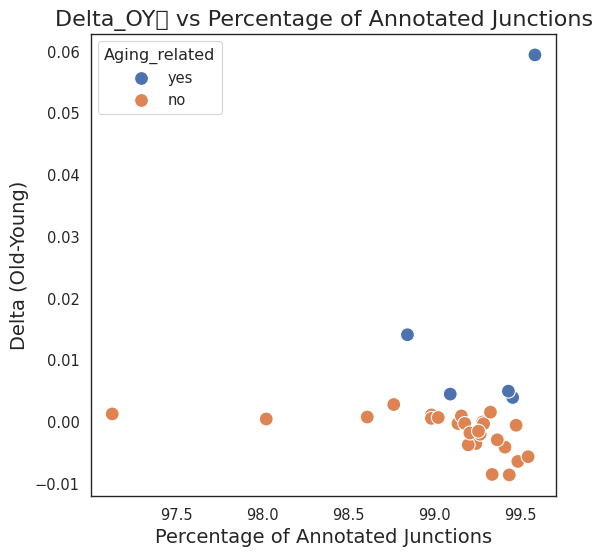

In [94]:
# let's plot coefficient vs annotated percentage for each factor
plt.figure(figsize=(6, 6))
sns.scatterplot(data=junc_anno_factors_df, x="annotated_percent", y="Delta_OY",s=100, hue="Aging_related")
plt.xlabel("Percentage of Annotated Junctions", fontsize=14)
# make xlim 80 to 100
plt.ylabel("Delta (Old-Young)", fontsize=14)
plt.title("Delta_OY	 vs Percentage of Annotated Junctions", fontsize=16)

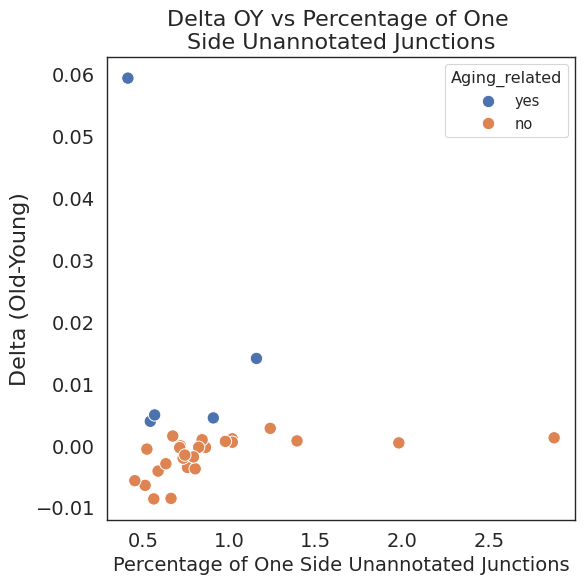

In [96]:
# let's plot coefficient vs annotated percentage for each factor
plt.figure(figsize=(6, 6))
sns.scatterplot(data=junc_anno_factors_df, x="one_side_percent", y="Delta_OY",s=80, hue="Aging_related")
plt.xlabel("Percentage of One Side Unannotated Junctions", fontsize=14)
plt.ylabel("Delta (Old-Young)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("Delta OY vs Percentage of One \nSide Unannotated Junctions", fontsize=16)
plt.tight_layout()
# save as pdf in /gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis
plt.savefig("/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/Delta_OY_vs_Percentage_of_One_Side_Unannotated_Junctions.pdf", format='pdf')

In [98]:
junc_anno_factors_df.sort_values(by="annotated_percent")

,both,five_prime,three_prime,unannotated,annotated_percent,unannotated_percent,one_side_percent,Factor,Delta_OY,Coefficient,Lower CI,Upper CI,Standard Error,Aging_related
27,19481,352,225,0,97.123342,0.0,2.876658,factor_28,0.001267,-3.074955,-3.598995,-2.550916,0.267369,no
26,19661,246,151,0,98.020740,0.0,1.979260,factor_27,0.000449,-0.992718,-1.714228,-0.271207,0.368120,no
21,19779,172,107,0,98.609034,0.0,1.390966,factor_22,0.000768,-2.475024,-3.159783,-1.790265,0.349369,no
10,19810,158,90,0,98.763586,0.0,1.236414,factor_11,0.002791,3.960820,3.463998,4.457642,0.253482,no
0,19826,136,96,0,98.843354,0.0,1.156646,factor_1,0.014092,7.984191,7.788607,8.179775,0.099788,yes
12,19854,135,69,0,98.982949,0.0,1.017051,factor_13,0.001106,1.848444,1.498572,2.198316,0.178507,no
13,19854,126,78,0,98.982949,0.0,1.017051,factor_14,0.000551,-4.557127,-5.103523,-4.010731,0.278775,no
28,19862,128,68,0,99.022834,0.0,0.977166,factor_29,0.000688,1.683859,1.192163,2.175556,0.250867,no
24,19876,126,56,0,99.092631,0.0,0.907369,factor_25,0.004481,9.911939,9.346417,10.477461,0.288534,yes
11,19885,114,59,0,99.137501,0.0,0.862499,factor_12,-0.000280,0.305298,-0.022257,0.632852,0.167121,no
